# Sharpe Ratio Validation Tests (Replay-Based)

Stress-tests using the **day-by-day replay engine** (`SimulationEngine.run_replay`) — the same
sequential pipeline the VM uses in production. This is more realistic than the vectorized backtest
because it processes one day at a time with proper position tracking, order flow, and compounding.

| Test | What It Checks | Key Metric |
|------|---------------|------------|
| **T+1 Execution** | Alpha decay — can you still profit if you trade on next-day prices? | Sharpe delta |
| **Out-of-Universe** | Survivorship bias — does the strategy work on random stocks too? | OOU Sharpe vs baseline |
| **Slippage Stress** | Market impact — at what cost level does the edge vanish? | Break-even slippage |

> **Prerequisite:** Run `main_mean_reversion.ipynb` first to generate bridge data.

In [1]:
# ============================================================================
# CELL 1: LOAD BRIDGE DATA + REPLAY ENGINE SETUP
# ============================================================================
import gc
gc.collect()

%load_ext autoreload
%autoreload 2

import sys, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Resolve project root
project_root = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

from strategy_config import ConfigLoader
from backtest.engine import BacktestConfig
from connection.alpaca_connection import AlpacaConfig, AlpacaConnection, TradingMode
from execution.alpaca_executor import AlpacaExecutor
from execution.simulation import SimulationEngine

# ── Load bridge data ──
_bridge_path = project_root / 'data' / 'snapshots' / 'notebook_bridge' / 'core_results.pkl'
with open(_bridge_path, 'rb') as f:
    _bridge = pickle.load(f)

results      = _bridge['results']       # 20-year backtest baseline (reference only)
bt_config    = _bridge['bt_config']
config       = ConfigLoader(Path(_bridge['config_path']))
price_df     = _bridge['price_df']
signal_df    = _bridge['signal_df']
volume_df    = _bridge['volume_df']
zscore_df    = _bridge['zscore_df']
analysis_df  = _bridge['analysis_df']
all_data     = _bridge['all_data']
mean_reverting_symbols = _bridge['mean_reverting_symbols']

del _bridge
gc.collect()

# ── Replay window: last 2 years ──
REPLAY_YEARS = 2
replay_end   = signal_df.index.max()
replay_start = replay_end - pd.DateOffset(years=REPLAY_YEARS)
replay_mask  = signal_df.index >= replay_start

r_price_df   = price_df.loc[replay_mask]
r_signal_df  = signal_df.loc[replay_mask]
r_volume_df  = volume_df.loc[replay_mask]
r_zscore_df  = zscore_df.loc[replay_mask]

# ── Helper: create a fresh SimulationEngine for replay ──
def create_replay_engine(cfg, slippage_override=None):
    """Create a SimulationEngine configured for replay mode."""
    alpaca_cfg = AlpacaConfig(
        api_key='REPLAY', secret_key='REPLAY',
        paper=True, trading_mode=TradingMode.REPLAY
    )
    conn = AlpacaConnection(alpaca_cfg)
    executor = AlpacaExecutor(
        connection=conn,
        commission_pct=cfg.commission_pct,
        max_position_pct=getattr(cfg, 'max_position_size', 0.10),
        max_total_exposure=getattr(cfg, 'max_total_exposure', 1.0),
        stop_loss_pct=getattr(cfg, 'stop_loss_pct', None),
        take_profit_pct=getattr(cfg, 'take_profit_pct', None),
    )
    slip = slippage_override if slippage_override is not None else getattr(cfg, 'slippage_pct', 0.0005)
    return SimulationEngine(
        executor=executor,
        initial_capital=cfg.initial_capital,
        commission_pct=cfg.commission_pct,
        slippage_pct=slip,
        commission_model=getattr(cfg, 'commission_model', 'flat'),
    )

def compute_derived(res, initial_capital=None):
    """Compute CAGR, profit factor, avg holding days from replay result dict."""
    eq = res['equity_curve']
    cap = initial_capital or eq.iloc[0]
    n_days = len(eq)
    cagr = (eq.iloc[-1] / cap) ** (252 / max(n_days, 1)) - 1 if cap > 0 else 0.0

    trades = res.get('trades_df')
    pf, avg_hold = 0.0, 0.0
    if trades is not None and len(trades) > 0:
        if 'pnl' in trades.columns:
            wins   = trades.loc[trades['pnl'] > 0, 'pnl'].sum()
            losses = abs(trades.loc[trades['pnl'] < 0, 'pnl'].sum())
            pf = wins / losses if losses > 0 else float('inf')
        if 'holding_days' in trades.columns:
            avg_hold = trades['holding_days'].mean()
    return {'cagr': cagr, 'profit_factor': pf, 'avg_holding_days': avg_hold}

print('✓ Bridge data loaded — replay engine ready')
print(f'  Symbols: {len(signal_df.columns)}')
print(f'  Full date range:  {signal_df.index.min().strftime("%Y-%m-%d")} → {signal_df.index.max().strftime("%Y-%m-%d")}')
print(f'  Replay window:    {r_signal_df.index.min().strftime("%Y-%m-%d")} → {r_signal_df.index.max().strftime("%Y-%m-%d")} ({len(r_signal_df)} days)')
print(f'\n  20y Backtest reference (not used in tests):')
print(f'    Sharpe: {results.sharpe_ratio:.2f}  |  CAGR: {results.annualized_return*100:.2f}%  |  MaxDD: {results.max_drawdown*100:.2f}%')


✓ Bridge data loaded — replay engine ready
  Symbols: 216
  Full date range:  2006-02-14 → 2026-02-13
  Replay window:    2024-02-13 → 2026-02-13 (503 days)

  20y Backtest reference (not used in tests):
    Sharpe: 3.25  |  CAGR: 42.06%  |  MaxDD: 14.00%


## Test 1: T+1 Execution Lag

**Question:** If we can only act on signals the *next* trading day (using next-day close prices), how much alpha decays?

**Method:**
- Shift `signal_df` forward by 1 day: day T's signal triggers day T+1's entry/exit
- Run **replay** (day-by-day simulation) with both original and shifted signals
- Compare Sharpe, CAGR, drawdown over the 2-year replay window

**Interpretation:**
- Sharpe drops < 20%: alpha is persistent, timing isn't critical
- Sharpe drops 20-50%: moderate decay, same-day execution matters
- Sharpe drops > 50%: strategy heavily relies on same-day fill (fragile)


In [2]:
# ============================================================================
# CELL 2: T+1 EXECUTION LAG TEST (REPLAY)
# ============================================================================
print("=" * 80)
print("TEST 1: T+1 EXECUTION LAG (Replay Engine)")
print("=" * 80)

# ── Shift signals forward by 1 day ──
signal_df_t1 = r_signal_df.shift(1)
zscore_df_t1 = r_zscore_df.shift(1)

# Drop first row (NaN from shift)
valid_mask = signal_df_t1.index[1:]
signal_df_t1 = signal_df_t1.loc[valid_mask]
zscore_df_t1 = zscore_df_t1.loc[valid_mask]
price_df_t1  = r_price_df.loc[valid_mask]
volume_df_t1 = r_volume_df.loc[valid_mask]

print(f"  Signal shift: 1 day forward (T signal → T+1 execution)")
print(f"  Date range:   {valid_mask.min().strftime('%Y-%m-%d')} → {valid_mask.max().strftime('%Y-%m-%d')}")
print(f"  Trading days: {len(valid_mask)}")

# ── Baseline replay (unshifted signals, same truncated window) ──
print("\n  Running baseline replay...")
sim_base = create_replay_engine(bt_config)
t0 = time.perf_counter()
results_base_trunc = sim_base.run_replay(
    price_df_t1, r_signal_df.loc[valid_mask], volume_df_t1,
    exit_signal_df=r_zscore_df.loc[valid_mask],
    config=bt_config, verbose=False
)
elapsed_base = time.perf_counter() - t0
derived_base = compute_derived(results_base_trunc, bt_config.initial_capital)
print(f"  Baseline done in {elapsed_base:.1f}s")

# ── T+1 replay (shifted signals) ──
print("  Running T+1 replay...")
sim_t1 = create_replay_engine(bt_config)
t0 = time.perf_counter()
results_t1 = sim_t1.run_replay(
    price_df_t1, signal_df_t1, volume_df_t1,
    exit_signal_df=zscore_df_t1,
    config=bt_config, verbose=False
)
elapsed_t1 = time.perf_counter() - t0
derived_t1 = compute_derived(results_t1, bt_config.initial_capital)
print(f"  T+1 done in {elapsed_t1:.1f}s")

# ── Results comparison ──
sharpe_base = results_base_trunc['sharpe_ratio']
sharpe_t1   = results_t1['sharpe_ratio']
sharpe_pct  = (sharpe_t1 - sharpe_base) / abs(sharpe_base) * 100 if sharpe_base != 0 else float('nan')

print(f"\n{'Metric':30s} {'Baseline (T+0)':>18s} {'T+1 Lag':>18s} {'Delta':>12s}")
print("-" * 80)
metrics = [
    ('Sharpe Ratio',  f'{sharpe_base:.2f}',  f'{sharpe_t1:.2f}',  f'{sharpe_pct:+.1f}%'),
    ('CAGR',          f'{derived_base["cagr"]*100:.2f}%', f'{derived_t1["cagr"]*100:.2f}%',
     f'{(derived_t1["cagr"] - derived_base["cagr"])*100:+.2f}pp'),
    ('Max Drawdown',  f'{results_base_trunc["max_drawdown_pct"]:.2f}%', f'{results_t1["max_drawdown_pct"]:.2f}%',
     f'{results_t1["max_drawdown_pct"] - results_base_trunc["max_drawdown_pct"]:+.2f}pp'),
    ('Win Rate',      f'{results_base_trunc["win_rate"]:.1f}%', f'{results_t1["win_rate"]:.1f}%',
     f'{results_t1["win_rate"] - results_base_trunc["win_rate"]:+.1f}pp'),
    ('Total Trades',  f'{results_base_trunc["total_trades"]}', f'{results_t1["total_trades"]}', ''),
    ('Profit Factor', f'{derived_base["profit_factor"]:.2f}', f'{derived_t1["profit_factor"]:.2f}', ''),
    ('Avg Holding',   f'{derived_base["avg_holding_days"]:.1f}d', f'{derived_t1["avg_holding_days"]:.1f}d', ''),
    ('Final Equity',  f'${results_base_trunc["final_equity"]:,.0f}',
     f'${results_t1["final_equity"]:,.0f}', ''),
]
for name, base_val, t1_val, delta in metrics:
    print(f'{name:30s} {base_val:>18s} {t1_val:>18s} {delta:>12s}')

# ── Verdict ──
print(f"\n{'─'*80}")
if abs(sharpe_pct) < 20:
    verdict = "✅ PASS — Alpha is persistent. T+1 execution has minimal impact."
elif abs(sharpe_pct) < 50:
    verdict = "⚠️  MODERATE — Some alpha decay. Same-day execution matters."
else:
    verdict = "❌ FRAGILE — Strategy relies heavily on same-day fill. T+1 destroys most alpha."
print(f"  {verdict}")
print(f"  Sharpe decay: {sharpe_pct:+.1f}%  ({sharpe_base:.2f} → {sharpe_t1:.2f})")
print(f"  Elapsed: {elapsed_base + elapsed_t1:.1f}s total")


TEST 1: T+1 EXECUTION LAG (Replay Engine)
  Signal shift: 1 day forward (T signal → T+1 execution)
  Date range:   2024-02-14 → 2026-02-13
  Trading days: 502

  Running baseline replay...


  Baseline done in 43.0s
  Running T+1 replay...
  T+1 done in 3.7s

Metric                             Baseline (T+0)            T+1 Lag        Delta
--------------------------------------------------------------------------------
Sharpe Ratio                                 6.90               3.51       -49.1%
CAGR                                      309.15%             94.11%    -215.03pp
Max Drawdown                               -6.18%             -9.12%      -2.94pp
Win Rate                                    66.4%              57.8%       -8.6pp
Total Trades                                 1564               1551             
Profit Factor                                2.32               1.55             
Avg Holding                                  2.7d               2.8d             
Final Equity                             $165,539            $37,482             

────────────────────────────────────────────────────────────────────────────────
  ⚠️  MODERATE — Some alpha de

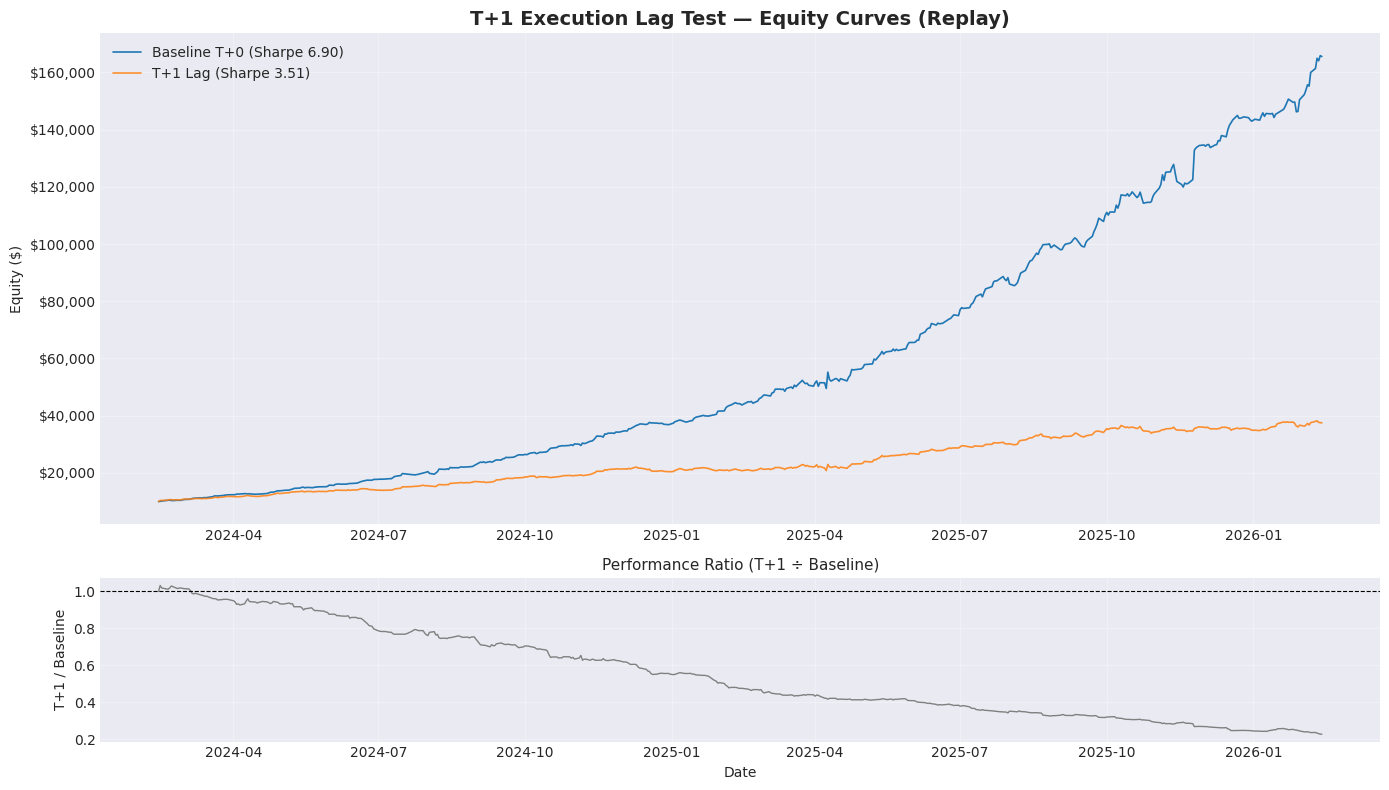

In [3]:
# ── T+1 Equity Curve Overlay ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Equity curves
eq_base = results_base_trunc['equity_curve']
eq_t1   = results_t1['equity_curve']
axes[0].plot(eq_base.index, eq_base.values, label=f'Baseline T+0 (Sharpe {sharpe_base:.2f})', linewidth=1.2)
axes[0].plot(eq_t1.index, eq_t1.values, label=f'T+1 Lag (Sharpe {sharpe_t1:.2f})', linewidth=1.2, alpha=0.85)
axes[0].set_title('T+1 Execution Lag Test — Equity Curves (Replay)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Equity ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x:,.0f}'))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Ratio: T+1 / Baseline
ratio = eq_t1.reindex(eq_base.index, method='ffill') / eq_base
axes[1].plot(ratio.index, ratio.values, color='gray', linewidth=1)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('T+1 / Baseline')
axes[1].set_xlabel('Date')
axes[1].set_title('Performance Ratio (T+1 ÷ Baseline)', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)


## Test 2: Out-of-Universe Placebo

**Question:** Does the strategy work on *random stocks* that were NOT selected by the Hurst/mean-reversion filter?

**Method:**
- Load all parquet files from `data/historical/daily/`
- Exclude the mean-reverting symbols already in the universe
- Generate fresh signals for out-of-universe stocks and run **replay**
- Compare replay Sharpe: in-universe vs out-of-universe on the same date range

**Why this matters:**
If Sharpe is high only on the curated universe and near-zero on random stocks, the edge is likely
real (Hurst filter genuinely selects mean-reverting stocks). If Sharpe is similar, the high
performance may be an artifact of data mining / look-ahead bias in universe selection.


In [4]:
# ============================================================================
# CELL 3: OUT-OF-UNIVERSE PLACEBO TEST (REPLAY)
# ============================================================================
print("=" * 80)
print("TEST 2: OUT-OF-UNIVERSE PLACEBO (Replay Engine)")
print("=" * 80)

from strategies.mean_reversion import MeanReversionSignals

# ── Load ALL parquet files ──
data_dir = project_root / 'data' / 'historical' / 'daily'
parquet_files = list(data_dir.glob('*.parquet'))
all_symbols_on_disk = [f.stem for f in parquet_files]

# ── Identify out-of-universe symbols ──
in_universe = set(mean_reverting_symbols)
oou_symbols = [s for s in all_symbols_on_disk if s not in in_universe]
print(f"  Total symbols on disk: {len(all_symbols_on_disk)}")
print(f"  In-universe (mean-reverting): {len(in_universe)}")
print(f"  Out-of-universe candidates: {len(oou_symbols)}")

if len(oou_symbols) < 10:
    print(f"\n⚠️  Not enough out-of-universe symbols for a meaningful test.")
    print(f"    Need at least 10; have {len(oou_symbols)}. Skipping.")
else:
    # ── Load out-of-universe data ──
    start_date, end_date = config.get_date_range()
    oou_data = {}
    for symbol in oou_symbols:
        try:
            df = pd.read_parquet(data_dir / f'{symbol}.parquet')
            if 'date' in df.columns:
                df['date'] = pd.to_datetime(df['date'])
                df = df.set_index('date').sort_index()
            if df.index.tz is not None:
                df.index = df.index.tz_localize(None)
            if start_date:
                df = df[df.index >= start_date]
            if end_date:
                df = df[df.index <= end_date]
            if len(df) >= 100:
                oou_data[symbol] = df
        except Exception:
            pass

    print(f"  Out-of-universe loaded (≥100 bars): {len(oou_data)}")

    # ── Generate signals for out-of-universe stocks ──
    signal_config = config.to_signal_config()
    signal_gen = MeanReversionSignals(signal_config)
    composite_weights = config.get_composite_weights()

    oou_price_data  = {s: df['close'] for s, df in oou_data.items()}
    oou_volume_data = {s: df['volume'] for s, df in oou_data.items()}

    oou_signals = {}
    oou_zscores = {}
    t0 = time.perf_counter()

    for symbol in oou_data:
        if symbol in oou_price_data and symbol in oou_volume_data:
            try:
                composite, individual = signal_gen.generate_composite_signal(
                    oou_price_data[symbol], oou_volume_data[symbol],
                    weights=composite_weights
                )
                oou_signals[symbol] = composite
                if 'zscore' in individual:
                    oou_zscores[symbol] = individual['zscore']
            except Exception:
                pass

    elapsed_sig = time.perf_counter() - t0
    print(f"  Signals generated for {len(oou_signals)} OOU symbols in {elapsed_sig:.1f}s")

    # ── Build DataFrames ──
    oou_price_df  = pd.DataFrame(oou_price_data)
    oou_volume_df = pd.DataFrame(oou_volume_data)
    oou_signal_df = pd.DataFrame(oou_signals)
    oou_zscore_df = pd.DataFrame(oou_zscores)

    # Align to common index
    common_idx = oou_price_df.index.intersection(oou_signal_df.index)
    oou_price_df  = oou_price_df.loc[common_idx]
    oou_volume_df = oou_volume_df.loc[common_idx]
    oou_signal_df = oou_signal_df.loc[common_idx]
    oou_zscore_df = oou_zscore_df.loc[common_idx]

    # Apply replay window (last 2 years)
    oou_replay_mask = common_idx >= replay_start
    oou_price_df  = oou_price_df.loc[oou_replay_mask]
    oou_volume_df = oou_volume_df.loc[oou_replay_mask]
    oou_signal_df = oou_signal_df.loc[oou_replay_mask]
    oou_zscore_df = oou_zscore_df.loc[oou_replay_mask]
    common_idx    = oou_price_df.index

    print(f"  OOU replay range: {common_idx.min().strftime('%Y-%m-%d')} → {common_idx.max().strftime('%Y-%m-%d')}")
    print(f"  OOU trading days: {len(common_idx)}")

    # ── Run OOU replay ──
    print("\n  Running OOU replay...")
    sim_oou = create_replay_engine(bt_config)
    t0 = time.perf_counter()
    results_oou = sim_oou.run_replay(
        oou_price_df, oou_signal_df, oou_volume_df,
        exit_signal_df=oou_zscore_df,
        config=bt_config, verbose=False
    )
    elapsed_oou = time.perf_counter() - t0
    derived_oou = compute_derived(results_oou, bt_config.initial_capital)
    print(f"  OOU replay done in {elapsed_oou:.1f}s")

    # ── In-universe baseline replay on same date range ──
    print("  Running in-universe baseline replay...")
    base_mask = r_price_df.index.intersection(common_idx)
    sim_base2 = create_replay_engine(bt_config)
    results_base2 = sim_base2.run_replay(
        r_price_df.loc[base_mask], r_signal_df.loc[base_mask], r_volume_df.loc[base_mask],
        exit_signal_df=r_zscore_df.loc[base_mask],
        config=bt_config, verbose=False
    )
    derived_base2 = compute_derived(results_base2, bt_config.initial_capital)
    print(f"  In-universe baseline done")

    # ── Results ──
    print(f"\n{'Metric':30s} {'In-Universe':>18s} {'Out-of-Universe':>18s}")
    print("-" * 70)
    oou_metrics = [
        ('Symbols',        f'{len(r_signal_df.columns)}', f'{len(oou_signal_df.columns)}'),
        ('Sharpe Ratio',   f'{results_base2["sharpe_ratio"]:.2f}', f'{results_oou["sharpe_ratio"]:.2f}'),
        ('CAGR',           f'{derived_base2["cagr"]*100:.2f}%', f'{derived_oou["cagr"]*100:.2f}%'),
        ('Max Drawdown',   f'{results_base2["max_drawdown_pct"]:.2f}%', f'{results_oou["max_drawdown_pct"]:.2f}%'),
        ('Win Rate',       f'{results_base2["win_rate"]:.1f}%', f'{results_oou["win_rate"]:.1f}%'),
        ('Total Trades',   f'{results_base2["total_trades"]}', f'{results_oou["total_trades"]}'),
        ('Profit Factor',  f'{derived_base2["profit_factor"]:.2f}', f'{derived_oou["profit_factor"]:.2f}'),
        ('Avg Holding',    f'{derived_base2["avg_holding_days"]:.1f}d', f'{derived_oou["avg_holding_days"]:.1f}d'),
        ('Final Equity',   f'${results_base2["final_equity"]:,.0f}',
         f'${results_oou["final_equity"]:,.0f}'),
    ]
    for name, iu, oou in oou_metrics:
        print(f'{name:30s} {iu:>18s} {oou:>18s}')

    # ── Verdict ──
    sharpe_ratio_oou = results_oou['sharpe_ratio'] / results_base2['sharpe_ratio'] if results_base2['sharpe_ratio'] != 0 else float('nan')
    print(f"\n{'─'*70}")
    if results_oou['total_trades'] < 10:
        verdict = "⚠️  INCONCLUSIVE — Too few OOU trades for reliable comparison."
    elif sharpe_ratio_oou > 0.8:
        verdict = "⚠️  WARNING — OOU Sharpe is close to in-universe. Edge may be generic / data-mined."
    elif sharpe_ratio_oou > 0.3:
        verdict = "✅ PLAUSIBLE — Universe filter adds meaningful alpha but some edge is generic."
    else:
        verdict = "✅ STRONG — Universe filter is the primary edge. Strategy is selective, not overfit."
    print(f"  {verdict}")
    print(f"  OOU Sharpe / In-Universe Sharpe = {sharpe_ratio_oou:.2f}")
    print(f"  Elapsed: signals {elapsed_sig:.1f}s + replay {elapsed_oou:.1f}s")


TEST 2: OUT-OF-UNIVERSE PLACEBO (Replay Engine)


  Total symbols on disk: 294
  In-universe (mean-reverting): 216
  Out-of-universe candidates: 78
  Out-of-universe loaded (≥100 bars): 78
  Signals generated for 78 OOU symbols in 2.4s
  OOU replay range: 2024-02-13 → 2026-02-13
  OOU trading days: 503

  Running OOU replay...
  OOU replay done in 15.2s
  Running in-universe baseline replay...
  In-universe baseline done

Metric                                In-Universe    Out-of-Universe
----------------------------------------------------------------------
Symbols                                       216                 78
Sharpe Ratio                                 6.99               6.19
CAGR                                      314.27%            147.02%
Max Drawdown                               -6.18%             -3.96%
Win Rate                                    66.7%              67.6%
Total Trades                                 1564                966
Profit Factor                                2.32               3.15
A

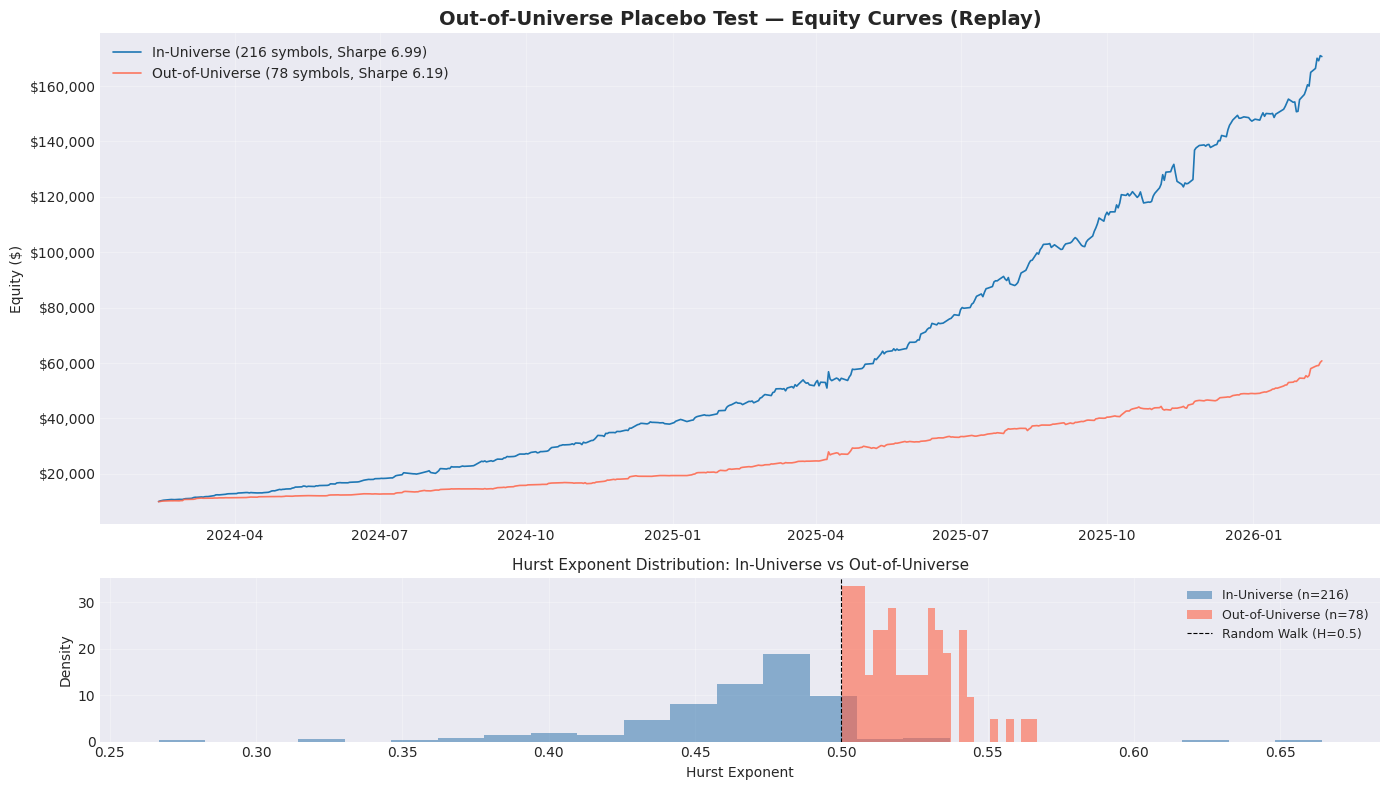

In [5]:
# ── Out-of-Universe Equity Curve Overlay ──
if len(oou_symbols) >= 10:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

    eq_iu  = results_base2['equity_curve']
    eq_oou = results_oou['equity_curve']

    axes[0].plot(eq_iu.index, eq_iu.values,
                 label=f'In-Universe ({len(r_signal_df.columns)} symbols, Sharpe {results_base2["sharpe_ratio"]:.2f})',
                 linewidth=1.2)
    axes[0].plot(eq_oou.index, eq_oou.values,
                 label=f'Out-of-Universe ({len(oou_signal_df.columns)} symbols, Sharpe {results_oou["sharpe_ratio"]:.2f})',
                 linewidth=1.2, alpha=0.85, color='tomato')
    axes[0].set_title('Out-of-Universe Placebo Test — Equity Curves (Replay)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Equity ($)')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x:,.0f}'))
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Hurst distribution comparison
    oou_hursts = []
    for s in oou_data:
        try:
            h = signal_gen.calculate_hurst_exponent(oou_data[s]['close'])
            if h is not None:
                oou_hursts.append(h)
        except Exception:
            pass

    iu_hursts = analysis_df[analysis_df['symbol'].isin(mean_reverting_symbols)]['hurst'].dropna().tolist()

    axes[1].hist(iu_hursts, bins=25, alpha=0.6, label=f'In-Universe (n={len(iu_hursts)})', color='steelblue', density=True)
    axes[1].hist(oou_hursts, bins=25, alpha=0.6, label=f'Out-of-Universe (n={len(oou_hursts)})', color='tomato', density=True)
    axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=0.8, label='Random Walk (H=0.5)')
    axes[1].set_xlabel('Hurst Exponent')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Hurst Exponent Distribution: In-Universe vs Out-of-Universe', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    print("Skipped — not enough OOU symbols.")


## Test 3: Slippage Stress Test

**Question:** At what slippage level does the strategy's edge break even?

**Method:**
- Re-run the **replay** (day-by-day simulation) at multiple slippage levels: 0, 5, 10, 20, 50, 100 bps
- Each run creates a fresh `SimulationEngine` with a different `slippage_pct` — so position sizing,
  stop-loss triggers, compounding, and order flow are all properly recalculated at each level
- The break-even slippage shows how much market impact the strategy can absorb before losing money

**Interpretation:**
- Break-even > 50 bps: Very robust (typical institutional slippage is 5-20 bps)
- Break-even 20-50 bps: Solid for liquid large-caps
- Break-even < 20 bps: Fragile — needs careful execution to remain profitable


In [6]:
# ============================================================================
# CELL 4: SLIPPAGE STRESS TEST (replay re-run at each level)
# ============================================================================
print("=" * 80)
print("TEST 3: SLIPPAGE STRESS TEST (Replay Engine)")
print("=" * 80)

slippage_levels_bps = [0, 5, 10, 20, 50, 100]  # basis points
slippage_results = {}
slippage_derived = {}

t0_all = time.perf_counter()

for bps in slippage_levels_bps:
    slip_pct = bps / 10000.0  # Convert bps to decimal
    sim_slip = create_replay_engine(bt_config, slippage_override=slip_pct)

    t0 = time.perf_counter()
    res = sim_slip.run_replay(
        r_price_df, r_signal_df, r_volume_df,
        exit_signal_df=r_zscore_df,
        config=bt_config, verbose=False
    )
    elapsed = time.perf_counter() - t0
    drv = compute_derived(res, bt_config.initial_capital)

    slippage_results[bps] = res
    slippage_derived[bps] = drv
    print(f"  {bps:>4d} bps ({slip_pct*100:.2f}%): Sharpe={res['sharpe_ratio']:>6.2f}  "
          f"CAGR={drv['cagr']*100:>7.2f}%  MaxDD={res['max_drawdown_pct']:>6.2f}%  "
          f"Trades={res['total_trades']:>5d}  ({elapsed:.1f}s)")

elapsed_total = time.perf_counter() - t0_all

# ── Results table ──
print(f"\n{'Slippage':>10s} {'Sharpe':>8s} {'CAGR':>10s} {'MaxDD':>8s} {'Win%':>8s} {'PF':>8s} {'Trades':>8s} {'Final Eq':>14s}")
print("-" * 80)
for bps in slippage_levels_bps:
    r = slippage_results[bps]
    d = slippage_derived[bps]
    print(f"  {bps:>4d} bps  {r['sharpe_ratio']:>8.2f} {d['cagr']*100:>9.2f}% "
          f"{r['max_drawdown_pct']:>7.2f}% {r['win_rate']:>7.1f}% {d['profit_factor']:>7.2f} "
          f"{r['total_trades']:>7d}  ${r['final_equity']:>12,.0f}")

# ── Find break-even slippage (interpolate where Sharpe → 0) ──
bps_arr = np.array(slippage_levels_bps, dtype=float)
sharpe_arr = np.array([slippage_results[b]['sharpe_ratio'] for b in slippage_levels_bps])

breakeven_bps = None
for i in range(len(sharpe_arr) - 1):
    if sharpe_arr[i] > 0 and sharpe_arr[i+1] <= 0:
        frac = sharpe_arr[i] / (sharpe_arr[i] - sharpe_arr[i+1])
        breakeven_bps = bps_arr[i] + frac * (bps_arr[i+1] - bps_arr[i])
        break

if breakeven_bps is None and sharpe_arr[-1] > 0:
    breakeven_bps = float('inf')  # Still profitable at max tested slippage
elif breakeven_bps is None:
    breakeven_bps = 0.0

print(f"\n{'─'*80}")
if breakeven_bps == float('inf'):
    print(f"  ✅ VERY ROBUST — Strategy remains profitable even at {slippage_levels_bps[-1]} bps slippage")
    print(f"     Sharpe at {slippage_levels_bps[-1]} bps: {sharpe_arr[-1]:.2f}")
elif breakeven_bps > 50:
    print(f"  ✅ ROBUST — Break-even slippage: {breakeven_bps:.0f} bps (well above typical 5-20 bps)")
elif breakeven_bps > 20:
    print(f"  ⚠️  ADEQUATE — Break-even slippage: {breakeven_bps:.0f} bps (viable for liquid stocks)")
else:
    print(f"  ❌ FRAGILE — Break-even slippage: {breakeven_bps:.0f} bps (very tight margin)")
print(f"  Total elapsed: {elapsed_total:.1f}s")


TEST 3: SLIPPAGE STRESS TEST (Replay Engine)


     0 bps (0.00%): Sharpe=  7.89  CAGR= 413.13%  MaxDD= -5.95%  Trades= 1563  (4.2s)
     5 bps (0.05%): Sharpe=  7.40  CAGR= 357.40%  MaxDD= -6.06%  Trades= 1568  (4.4s)
    10 bps (0.10%): Sharpe=  6.99  CAGR= 314.27%  MaxDD= -6.18%  Trades= 1564  (4.2s)
    20 bps (0.20%): Sharpe=  5.84  CAGR= 226.13%  MaxDD= -6.41%  Trades= 1575  (4.3s)
    50 bps (0.50%): Sharpe=  2.46  CAGR=  61.08%  MaxDD= -8.42%  Trades= 1582  (4.1s)
   100 bps (1.00%): Sharpe= -3.38  CAGR= -51.80%  MaxDD=-77.05%  Trades= 1734  (4.5s)

  Slippage   Sharpe       CAGR    MaxDD     Win%       PF   Trades       Final Eq
--------------------------------------------------------------------------------
     0 bps      7.89    413.13%   -5.95%    68.8%    2.64    1563  $     261,599
     5 bps      7.40    357.40%   -6.06%    67.5%    2.47    1568  $     207,957
    10 bps      6.99    314.27%   -6.18%    66.7%    2.32    1564  $     170,658
    20 bps      5.84    226.13%   -6.41%    64.3%    2.03    1575  $     105,

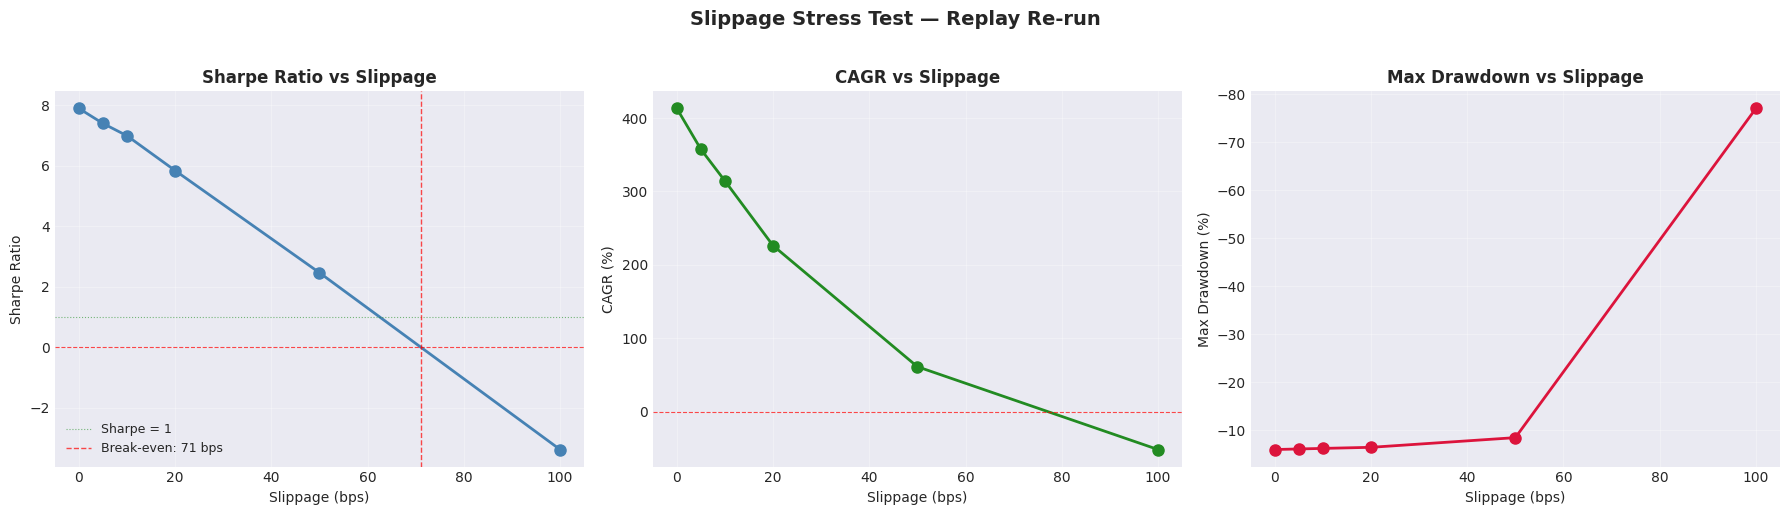

In [7]:
# ── Slippage Degradation Charts ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bps_list = slippage_levels_bps
sharpes  = [slippage_results[b]['sharpe_ratio'] for b in bps_list]
cagrs    = [slippage_derived[b]['cagr'] * 100 for b in bps_list]
maxdds   = [slippage_results[b]['max_drawdown_pct'] for b in bps_list]

# Sharpe vs Slippage
axes[0].plot(bps_list, sharpes, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].axhline(y=1, color='green', linestyle=':', linewidth=0.8, alpha=0.5, label='Sharpe = 1')
if breakeven_bps != float('inf') and breakeven_bps > 0:
    axes[0].axvline(x=breakeven_bps, color='red', linestyle='--', linewidth=1, alpha=0.7,
                    label=f'Break-even: {breakeven_bps:.0f} bps')
axes[0].set_xlabel('Slippage (bps)')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].set_title('Sharpe Ratio vs Slippage', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# CAGR vs Slippage
axes[1].plot(bps_list, cagrs, 'o-', color='forestgreen', linewidth=2, markersize=8)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
axes[1].set_xlabel('Slippage (bps)')
axes[1].set_ylabel('CAGR (%)')
axes[1].set_title('CAGR vs Slippage', fontweight='bold')
axes[1].grid(alpha=0.3)

# Max Drawdown vs Slippage
axes[2].plot(bps_list, maxdds, 'o-', color='crimson', linewidth=2, markersize=8)
axes[2].set_xlabel('Slippage (bps)')
axes[2].set_ylabel('Max Drawdown (%)')
axes[2].set_title('Max Drawdown vs Slippage', fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(alpha=0.3)

plt.suptitle('Slippage Stress Test — Replay Re-run', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)


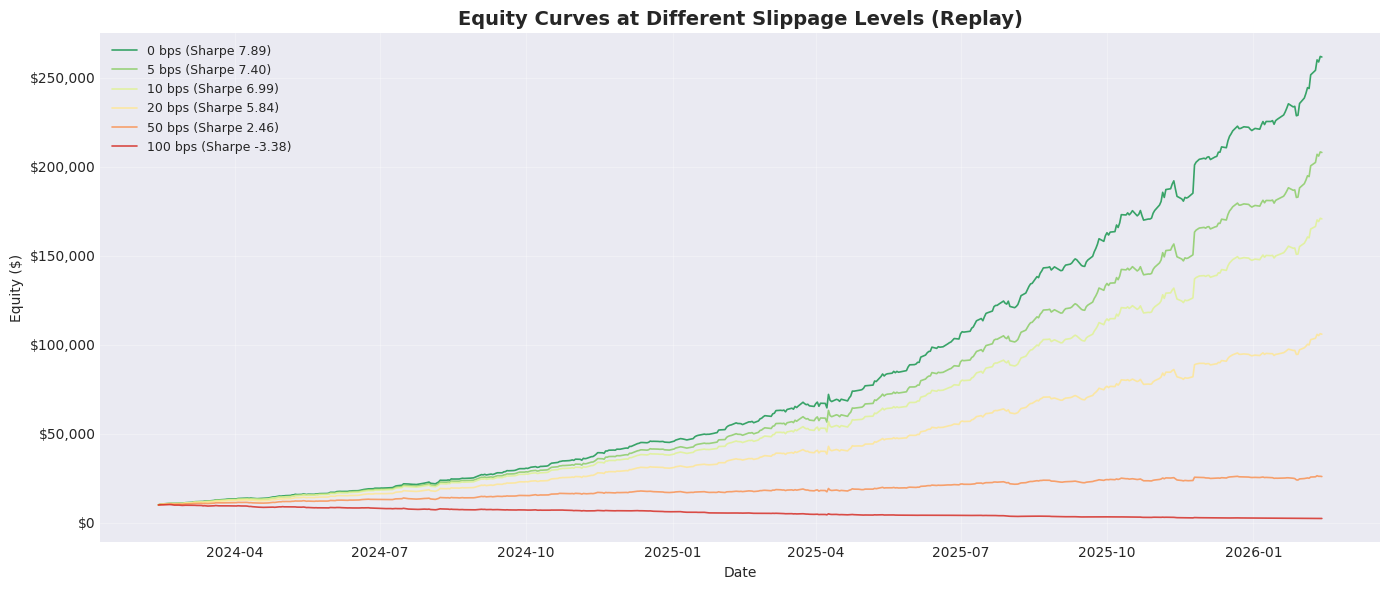

In [8]:
# ── Slippage Equity Curves Overlay ──
fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(slippage_levels_bps)))

for bps, color in zip(slippage_levels_bps, colors):
    eq = slippage_results[bps]['equity_curve']
    sharpe = slippage_results[bps]['sharpe_ratio']
    ax.plot(eq.index, eq.values, label=f'{bps} bps (Sharpe {sharpe:.2f})',
            linewidth=1.2, color=color, alpha=0.85)

ax.set_title('Equity Curves at Different Slippage Levels (Replay)', fontsize=14, fontweight='bold')
ax.set_ylabel('Equity ($)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x:,.0f}'))
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)


## Combined Validation Summary (Replay-Based)


In [9]:
# ============================================================================
# CELL 5: COMBINED VALIDATION SUMMARY (REPLAY-BASED)
# ============================================================================
print("=" * 90)
print("SHARPE RATIO VALIDATION SUMMARY (Replay Engine)")
print("=" * 90)

# Use the baseline from the T+1 test (full truncated replay) as reference
ref_sharpe = results_base_trunc['sharpe_ratio']
ref_cagr   = derived_base['cagr']
ref_maxdd  = results_base_trunc['max_drawdown_pct']

print(f"\n  Replay Baseline (2y):  Sharpe={ref_sharpe:.2f}  |  CAGR={ref_cagr*100:.2f}%  |  MaxDD={ref_maxdd:.2f}%")
print(f"  20y Backtest ref:      Sharpe={results.sharpe_ratio:.2f}  |  CAGR={results.annualized_return*100:.2f}%  |  MaxDD={results.max_drawdown*100:.2f}%")

print(f"\n{'─'*90}")
print(f"{'Test':35s} {'Result':>12s} {'Verdict':>40s}")
print("─" * 90)

# Init
oou_ratio = float('nan')

# T+1
t1_delta = (results_t1['sharpe_ratio'] - sharpe_base) / abs(sharpe_base) * 100 if sharpe_base != 0 else 0
if abs(t1_delta) < 20:
    t1_verdict = "✅ Alpha persistent"
elif abs(t1_delta) < 50:
    t1_verdict = "⚠️  Moderate decay"
else:
    t1_verdict = "❌ Fragile"
print(f"{'1. T+1 Execution Lag':35s} {t1_delta:>+10.1f}%   {t1_verdict:>40s}")

# Out-of-Universe
if len(oou_symbols) >= 10:
    oou_ratio = results_oou['sharpe_ratio'] / results_base2['sharpe_ratio'] if results_base2['sharpe_ratio'] != 0 else float('nan')
    if results_oou['total_trades'] < 10:
        oou_verdict = "⚠️  Inconclusive (few trades)"
    elif oou_ratio > 0.8:
        oou_verdict = "⚠️  Edge may be generic"
    elif oou_ratio > 0.3:
        oou_verdict = "✅ Filter adds alpha"
    else:
        oou_verdict = "✅ Strong selectivity"
    print(f"{'2. Out-of-Universe Placebo':35s} {oou_ratio:>10.2f}x   {oou_verdict:>40s}")
else:
    print(f"{'2. Out-of-Universe Placebo':35s} {'N/A':>12s}   {'⚠️  Not enough symbols':>40s}")

# Slippage
if breakeven_bps == float('inf'):
    slip_str = f">={slippage_levels_bps[-1]} bps"
    slip_verdict = "✅ Very robust"
elif breakeven_bps > 50:
    slip_str = f"{breakeven_bps:.0f} bps"
    slip_verdict = "✅ Robust"
elif breakeven_bps > 20:
    slip_str = f"{breakeven_bps:.0f} bps"
    slip_verdict = "⚠️  Adequate"
else:
    slip_str = f"{breakeven_bps:.0f} bps"
    slip_verdict = "❌ Fragile"
print(f"{'3. Slippage Break-Even':35s} {slip_str:>12s}   {slip_verdict:>40s}")

print("─" * 90)

# Overall assessment
tests_passed = 0
if abs(t1_delta) < 50: tests_passed += 1
if len(oou_symbols) >= 10 and results_oou['total_trades'] >= 10:
    if oou_ratio <= 0.8: tests_passed += 1
elif len(oou_symbols) < 10:
    tests_passed += 0.5  # Inconclusive = half credit
if breakeven_bps > 20: tests_passed += 1

print(f"\n  Overall: {tests_passed}/3 tests passed")
if tests_passed >= 2.5:
    print("  ✅ VERDICT: High Sharpe is largely justified. Strategy has genuine edge.")
elif tests_passed >= 1.5:
    print("  ⚠️  VERDICT: Mixed results. Some concerns but edge likely exists with caveats.")
else:
    print("  ❌ VERDICT: Significant concerns. Sharpe may be substantially inflated.")

print(f"\n  Remaining bias sources (cannot test in replay):")
print(f"    • Perfect fills (no partial fills, no rejections)")
print(f"    • No short borrow costs (funding fees not modeled)")
print(f"    • No market impact beyond slippage (large orders moving price)")
print(f"    • Survivorship bias in S&P 500 constituent list")
print(f"\n  → Compare with VM paper-trading Sharpe for ground truth.")


SHARPE RATIO VALIDATION SUMMARY (Replay Engine)

  Replay Baseline (2y):  Sharpe=6.90  |  CAGR=309.15%  |  MaxDD=-6.18%
  20y Backtest ref:      Sharpe=3.25  |  CAGR=42.06%  |  MaxDD=14.00%

──────────────────────────────────────────────────────────────────────────────────────────
Test                                      Result                                  Verdict
──────────────────────────────────────────────────────────────────────────────────────────
1. T+1 Execution Lag                     -49.1%                         ⚠️  Moderate decay
2. Out-of-Universe Placebo                0.89x                    ⚠️  Edge may be generic
3. Slippage Break-Even                    71 bps                                   ✅ Robust
──────────────────────────────────────────────────────────────────────────────────────────

  Overall: 2/3 tests passed
  ⚠️  VERDICT: Mixed results. Some concerns but edge likely exists with caveats.

  Remaining bias sources (cannot test in replay):
    • Perfe